# DenseNet121

**Pipeline:**
1. Mount Google Drive / clone repo (Colab setup)
2. Load dataset via HuggingFace `datasets`
3. Build DenseNet121 model
4. Train with frozen backbone → unfreeze → fine-tune
5. Evaluate on test set
6. Save metrics + plots

## 0. Colab setup
Run this cell only on **Google Colab**. Skip locally.

In [1]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # Adjust this path to wherever you cloned the repo in your Drive
    REPO_PATH = '/content/drive/MyDrive/Explainable-Glaucoma-Stage-Classification'
    %cd {REPO_PATH}

    !pip install -q datasets grad-cam captum

print('Working directory:', __import__('os').getcwd())

Working directory: /home/viet/workspace/viet/Explainable-Glaucoma-Stage-Classification


## 1. Imports & reproducibility

In [2]:
import torch
import torch.nn as nn

from src.training.config import (
    BATCH_SIZE, NUM_EPOCHS, LEARNING_RATE, WEIGHT_DECAY,
    NUM_CLASSES, DEVICE, set_seed,
)
from src.datasets.glaucoma_dataset import build_dataloaders
from src.models.densenet121 import DenseNet121Classifier
from src.training.train_loop import fit, evaluate
from src.utils.metrics import compute_metrics, save_metrics, print_report
from src.utils.visualize import plot_training_curves, plot_confusion_matrix

set_seed()
print(f'Device: {DEVICE}')

/home/viet/workspace/viet/Explainable-Glaucoma-Stage-Classification/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 2. Load data

In [3]:
train_loader, val_loader, test_loader = build_dataloaders(batch_size=BATCH_SIZE)

print(f'Train batches : {len(train_loader):>4} ({len(train_loader.dataset)} images)')
print(f'Val batches : {len(val_loader):>4} ({len(val_loader.dataset)} images)')
print(f'Test batches : {len(test_loader):>4} ({len(test_loader.dataset)} images)')

[WARNING] Detected duplicate images between train/val: 459, train/test: 358 -- needs to be processed before training.
After dedup: train 2341 (was 2847), val 1163 (was 1259), test 1221 (was 1272)
Train batches :   74 (2341 images)
Val batches :   37 (1163 images)
Test batches :   39 (1221 images)


## 3. Build model

In [4]:
model = DenseNet121Classifier(
    num_classes=NUM_CLASSES,
    pretrained=True,
    freeze_features=True,   # frozen backbone for Phase 1
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

Trainable params: 3,075 / 6,956,931


## 4. Phase 1 — Train classifier head only (frozen backbone)

Start with a frozen backbone so the randomly-initialised head converges quickly
without corrupting the pretrained features.

In [5]:
PHASE1_EPOCHS = 5

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE * 10,   # higher LR is fine while backbone is frozen
    weight_decay=WEIGHT_DECAY,
)

print("\n" + "="*60)
print("PHASE 1: Frozen Backbone")
print("="*60)

history_phase1 = fit(
    model, train_loader, val_loader,
    loss_fn, optimizer,
    num_epochs=PHASE1_EPOCHS,
    model_name="densenet121_phase1",
    patience=3,
)


PHASE 1: Frozen Backbone
Epoch 1/5 - train_loss: 0.9440 - val_loss: 0.8411  (best so far)
Epoch 2/5 - train_loss: 0.7941 - val_loss: 0.7692  (best so far)
Epoch 3/5 - train_loss: 0.7841 - val_loss: 0.7375  (best so far)
Epoch 4/5 - train_loss: 0.7456 - val_loss: 0.7145  (best so far)
Epoch 5/5 - train_loss: 0.7219 - val_loss: 0.7093  (best so far)


## 5. Phase 2 — Fine-tune full network (3 consecutive runs)

Unfreeze and run 3 blocks of 20 epochs each on the same model.
Each run saves a checkpoint and training curves for comparison.

PHASE 2 - RUN 1/3
Epoch 1/20 - train_loss: 0.6566 - val_loss: 0.5561  (best so far)
Epoch 2/20 - train_loss: 0.4902 - val_loss: 0.4601  (best so far)
Epoch 3/20 - train_loss: 0.3800 - val_loss: 0.4158  (best so far)
Epoch 4/20 - train_loss: 0.3080 - val_loss: 0.3529  (best so far)
Epoch 5/20 - train_loss: 0.2308 - val_loss: 0.2834  (best so far)
Epoch 6/20 - train_loss: 0.1671 - val_loss: 0.3073
Epoch 7/20 - train_loss: 0.1814 - val_loss: 0.2869
Epoch 8/20 - train_loss: 0.1123 - val_loss: 0.2552  (best so far)
Epoch 9/20 - train_loss: 0.1345 - val_loss: 0.2782
Epoch 10/20 - train_loss: 0.0805 - val_loss: 0.3194
Epoch 11/20 - train_loss: 0.0662 - val_loss: 0.2398  (best so far)
Epoch 12/20 - train_loss: 0.0979 - val_loss: 0.2805
Epoch 13/20 - train_loss: 0.0995 - val_loss: 0.4205
Epoch 14/20 - train_loss: 0.0624 - val_loss: 0.2496
Epoch 15/20 - train_loss: 0.0319 - val_loss: 0.2592
Epoch 16/20 - train_loss: 0.0252 - val_loss: 0.2970
No improvement for 5 epochs -- stopping early at epoch

/tmp/ipykernel_620142/1528665972.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Epoch 1/20 - train_loss: 0.0553 - val_loss: 0.3825  (best so far)
Epoch 2/20 - train_loss: 0.0596 - val_loss: 0.3367  (best so far)
Epoch 3/20 - train_loss: 0.0834 - val_loss: 0.3947
Epoch 4/20 - train_loss: 0.0866 - val_loss: 0.3576
Epoch 5/20 - train_loss: 0.0788 - val_loss: 0.2828  (best so far)
Epoch 6/20 - train_loss: 0.0621 - val_loss: 0.2824  (best so far)
Epoch 7/20 - train_loss: 0.0613 - val_loss: 0.2614  (best so far)
Epoch 8/20 - train_loss: 0.0411 - val_loss: 0.3156
Epoch 9/20 - train_loss: 0.0249 - val_loss: 0.2893
Epoch 10/20 - train_loss: 0.0263 - val_loss: 0.2907
Epoch 11/20 - train_loss: 0.0341 - val_loss: 0.2695
Epoch 12/20 - train_loss: 0.0245 - val_loss: 0.2479  (best so far)
Epoch 13/20 - train_loss: 0.0307 - val_loss: 0.3438
Epoch 14/20 - train_loss: 0.0217 - val_loss: 0.3554
Epoch 15/20 - train_loss: 0.0316 - val_loss: 0.2819
Epoch 16/20 - train_loss: 0.0227 - val_loss: 0.3163
Epoch 17/20 - train_loss: 0.0233 - val_loss: 0.3290
No improvement for 5 epochs -- stop

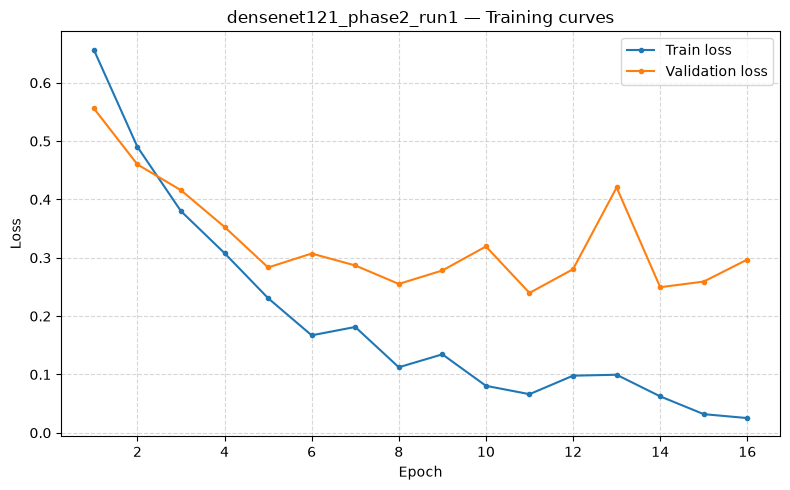

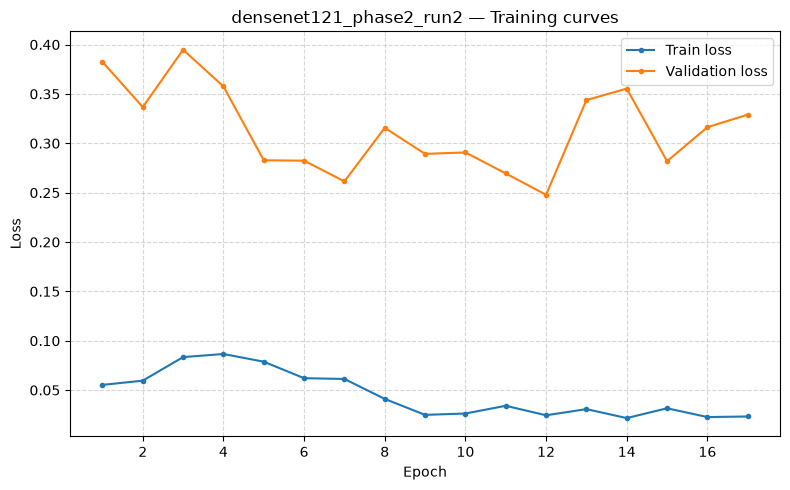

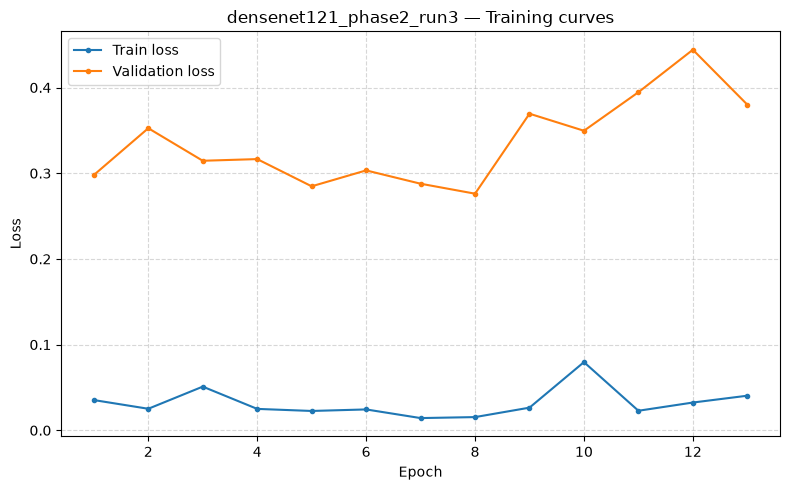

In [6]:
model.unfreeze_features()

NUM_PHASE2_RUNS = 3
PHASE2_EPOCHS = 20

all_phase2_histories = []

for run in range(1, NUM_PHASE2_RUNS + 1):
    print(f"{'='*60}")
    print(f"PHASE 2 - RUN {run}/{NUM_PHASE2_RUNS}")
    print(f"{'='*60}")

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    history_phase2 = fit(
        model, train_loader, val_loader,
        loss_fn, optimizer,
        num_epochs=PHASE2_EPOCHS,
        model_name=f"densenet121_phase2_run{run}",
        patience=5,
    )

    all_phase2_histories.append(history_phase2)
    
    # Plot this run
    fig = plot_training_curves(history_phase2, model_name=f"densenet121_phase2_run{run}")
    fig.show()
    
    print(f"Phase 2 Run {run} complete.")

## 6. Phase 1 training curve

Figure saved → results/figures/densenet121_phase1_training_curves.png


/tmp/ipykernel_620142/668600248.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


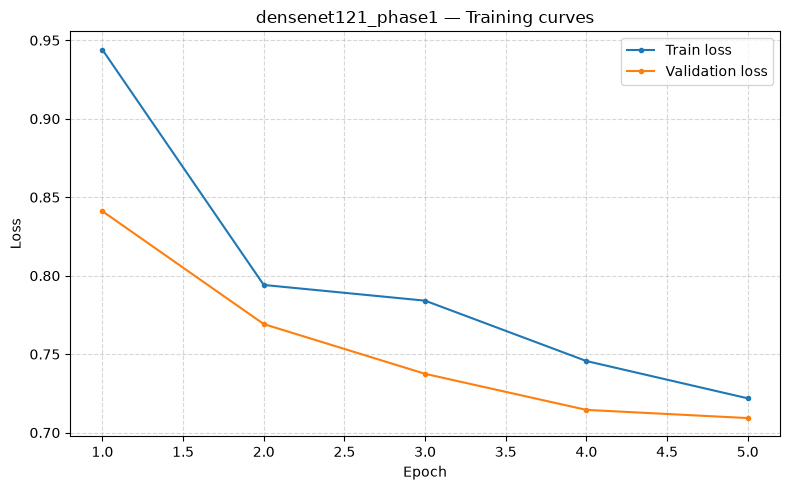

In [7]:
fig = plot_training_curves(history_phase1, model_name="densenet121_phase1")
fig.show()

## 7. Load best checkpoint & evaluate on test set

In [11]:
from src.training.config import CHECKPOINT_DIR
import os

# Load the best checkpoint 
best_ckpt = os.path.join(CHECKPOINT_DIR, "densenet121_phase2_run1_best.pt")
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
print(f"Loaded best checkpoint from {best_ckpt}")

# evaluate returns (loss, preds, labels)
test_loss, test_preds, test_labels = evaluate(model, test_loader, loss_fn)
print(f"Test loss: {test_loss:.4f}")

Loaded best checkpoint from checkpoints/densenet121_phase2_run1_best.pt
Test loss: 0.2592


## 8. Metrics

In [14]:
metrics = compute_metrics(test_labels, test_preds)

print(f"Accuracy : {metrics['accuracy']:.4f}")
print(f"F1 macro : {metrics['f1_macro']:.4f}")
print()
print_report(test_labels, test_preds)

save_metrics(metrics, model_name='densenet121')

Accuracy : 0.9099
F1 macro : 0.8981

              precision    recall  f1-score   support

      normal       0.96      0.90      0.93       573
       early       0.79      0.88      0.83       240
    advanced       0.92      0.95      0.93       408

    accuracy                           0.91      1221
   macro avg       0.89      0.91      0.90      1221
weighted avg       0.91      0.91      0.91      1221

Metrics saved → results/metrics/densenet121.json


'results/metrics/densenet121.json'

## 9. Confusion matrix

Figure saved → results/figures/densenet121_confusion_matrix.png


/tmp/ipykernel_620142/3183910754.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_cm.show()


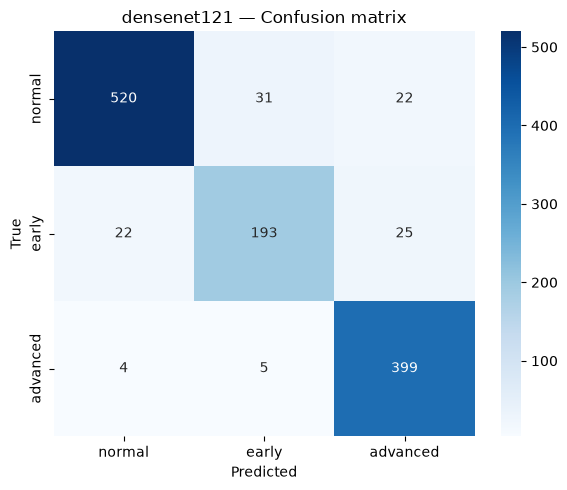

In [10]:
fig_cm = plot_confusion_matrix(metrics['confusion_matrix'], model_name='densenet121')
fig_cm.show()